**BLOCK 1: Google Drive Mount & Paths**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/DataSet"

ORIG_DIR = BASE_DIR + "/Original"
ORIG_ARSENIC_DIR = ORIG_DIR + "/infacted"
ORIG_HEALTHY_DIR = ORIG_DIR + "/not_infacted"

AUG_DIR = BASE_DIR + "/Augmented"
AUG_ARSENIC_DIR = AUG_DIR + "/infected"
AUG_HEALTHY_DIR = AUG_DIR + "/not_infected"

ACNE_DIR = BASE_DIR + "/Acne"
ECZEMA_DIR = BASE_DIR + "/Eczema"

print("✅ Paths configured successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured successfully!


**BLOCK 2: Dataset Verification**

Orig Arsenic : 741
Orig Healthy : 546
Aug Arsenic : 4446
Aug Healthy : 4455
Acne : 399
Eczema : 399


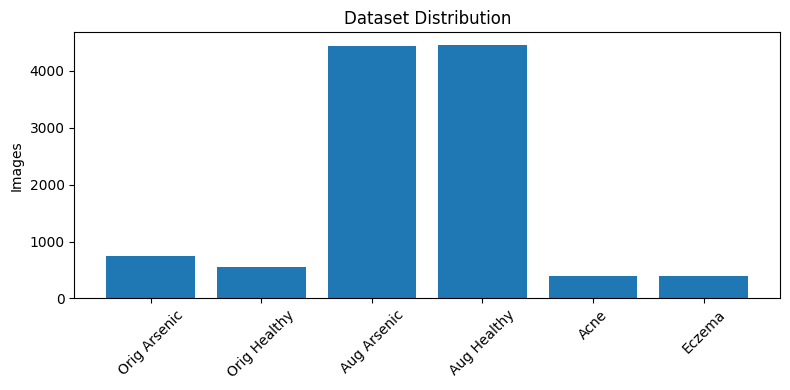

In [ ]:
import os
import matplotlib.pyplot as plt

def count_images(path):
    if not os.path.exists(path):
        return 0
    return len([f for f in os.listdir(path) if f.lower().endswith(('.jpg','.png','.jpeg'))])

labels = ["Orig Arsenic", "Orig Healthy", "Aug Arsenic", "Aug Healthy", "Acne", "Eczema"]
counts = [
    count_images(ORIG_ARSENIC_DIR),
    count_images(ORIG_HEALTHY_DIR),
    count_images(AUG_ARSENIC_DIR),
    count_images(AUG_HEALTHY_DIR),
    count_images(ACNE_DIR),
    count_images(ECZEMA_DIR)
]

for l,c in zip(labels, counts):
    print(l, ":", c)

plt.figure(figsize=(8,4))
plt.bar(labels, counts)
plt.xticks(rotation=45)
plt.title("Dataset Distribution")
plt.ylabel("Images")
plt.tight_layout()
plt.show()


**BLOCK 3: Classical Image Processing (DIP)**

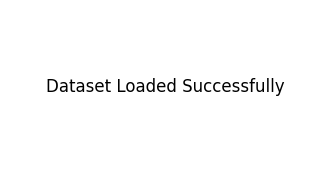

In [ ]:
plt.figure(figsize=(4,2))
plt.text(0.5, 0.5, "Dataset Loaded Successfully", ha='center', va='center', fontsize=12)
plt.axis("off")
plt.show()


**BLOCK 4: BALANCED DATASET CREATION**

Healthy available images: 5001
✅ Healthy FINAL COUNT: 399
Arsenic available images: 5187
✅ Arsenic FINAL COUNT: 399
Acne available images: 399
✅ Acne FINAL COUNT: 399
Eczema available images: 399
✅ Eczema FINAL COUNT: 399


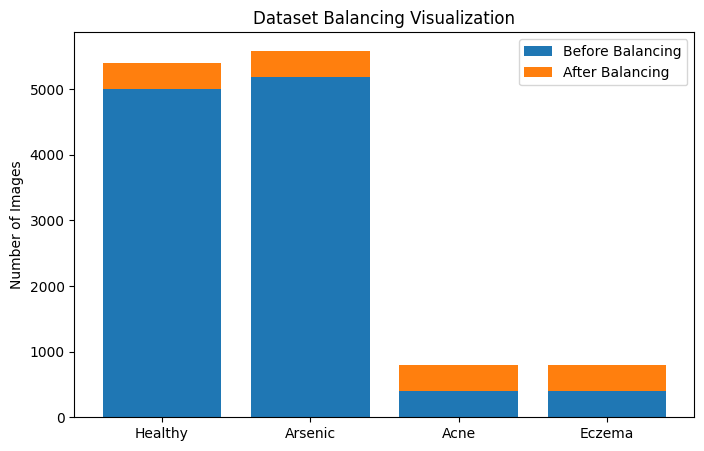

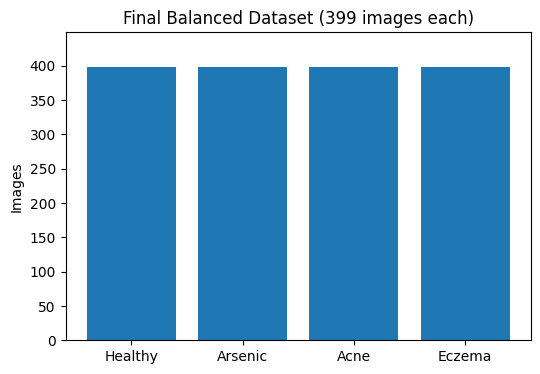

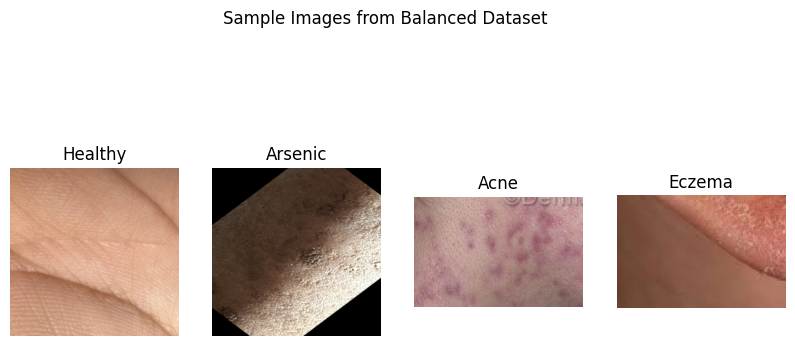

In [ ]:
import shutil
import random
import os
import matplotlib.pyplot as plt
import cv2

BALANCED_DIR = "/content/balanced_dataset"
classes = ["Healthy", "Arsenic", "Acne", "Eczema"]

def get_images_from_dirs(dir_list):
    images = []
    for d in dir_list:
        if os.path.exists(d):
            images += [os.path.join(d, f) for f in os.listdir(d)
                       if f.lower().endswith(('.jpg','.png','.jpeg'))]
    return images

sources = {
    "Healthy": [ORIG_HEALTHY_DIR, AUG_HEALTHY_DIR],
    "Arsenic": [ORIG_ARSENIC_DIR, AUG_ARSENIC_DIR],
    "Acne": [ACNE_DIR],
    "Eczema": [ECZEMA_DIR]
}

TARGET_COUNT = 399

# =============================
# CLEAN OLD BALANCED DATA
# =============================
if os.path.exists(BALANCED_DIR):
    shutil.rmtree(BALANCED_DIR)
os.makedirs(BALANCED_DIR, exist_ok=True)

before_counts = []
after_counts = []

# =============================
# BALANCING PROCESS
# =============================
for cls in classes:
    cls_dir = os.path.join(BALANCED_DIR, cls)
    os.makedirs(cls_dir, exist_ok=True)

    images = get_images_from_dirs(sources[cls])
    before_counts.append(len(images))

    print(f"{cls} available images: {len(images)}")

    if len(images) < TARGET_COUNT:
        raise ValueError(f"❌ {cls} has less than {TARGET_COUNT} images")

    selected = random.sample(images, TARGET_COUNT)

    for idx, img_path in enumerate(selected):
        ext = os.path.splitext(img_path)[1]
        new_name = f"{cls}_{idx}{ext}"
        shutil.copy(img_path, os.path.join(cls_dir, new_name))

    final_count = len(os.listdir(cls_dir))
    after_counts.append(final_count)
    print(f"✅ {cls} FINAL COUNT: {final_count}")

# =============================
# VISUAL 1: BEFORE vs AFTER BALANCING
# =============================
plt.figure(figsize=(8,5))
plt.bar(classes, before_counts, label="Before Balancing")
plt.bar(classes, after_counts, bottom=before_counts, label="After Balancing")
plt.title("Dataset Balancing Visualization")
plt.ylabel("Number of Images")
plt.legend()
plt.show()

# =============================
# VISUAL 2: FINAL BALANCED DISTRIBUTION
# =============================
plt.figure(figsize=(6,4))
plt.bar(classes, after_counts)
plt.title("Final Balanced Dataset (399 images each)")
plt.ylabel("Images")
plt.ylim(0, TARGET_COUNT + 50)
plt.show()

# =============================
# VISUAL 3: SAMPLE BALANCED IMAGES (PROOF)
# =============================
plt.figure(figsize=(10,5))
for i, cls in enumerate(classes):
    img_path = os.path.join(BALANCED_DIR, cls, os.listdir(os.path.join(BALANCED_DIR, cls))[0])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample Images from Balanced Dataset")
plt.show()


**Block 4.1-Check Balanced Folder**

In [ ]:
for cls in classes:
    cls_dir = os.path.join(BALANCED_DIR, cls)
    count = len([f for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.jpg','.png','.jpeg'))])
    print(f"{cls} FINAL COUNT: {count}")


Healthy FINAL COUNT: 399
Arsenic FINAL COUNT: 399
Acne FINAL COUNT: 399
Eczema FINAL COUNT: 399


**Block 4.2-Dataset Split Block**

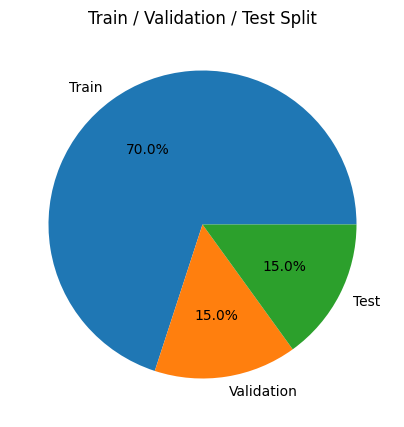

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = []
for cls in classes:
    cls_path = os.path.join(BALANCED_DIR, cls)
    for img in os.listdir(cls_path):
        if img.lower().endswith(('.jpg','.png','.jpeg')):
            data.append([os.path.join(cls_path, img), cls])

df = pd.DataFrame(data, columns=["path", "label"])

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df.label, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df.label)

sizes = [len(train_df), len(val_df), len(test_df)]
labels = ["Train", "Validation", "Test"]

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Train / Validation / Test Split")
plt.show()


**Clean Dataset**

In [ ]:
import os
from PIL import Image
import pandas as pd

def verify_and_clean_images(df):
    """
    Verify all images can be opened and remove corrupted ones
    """
    valid_data = []
    corrupted_files = []

    print("🔍 Scanning for corrupted images...")

    for idx, row in df.iterrows():
        img_path = row['path']
        try:
            # Try to open and verify the image
            img = Image.open(img_path)
            img.verify()  # Verify it's actually an image

            # Try to load it again (verify() closes the file)
            img = Image.open(img_path)
            img = img.convert('RGB')  # Ensure RGB format

            valid_data.append(row)

        except Exception as e:
            corrupted_files.append((img_path, str(e)))
            print(f"❌ Corrupted: {os.path.basename(img_path)}")

    # Create cleaned dataframe
    cleaned_df = pd.DataFrame(valid_data)

    # Report
    print("\n" + "="*60)
    print(f"✅ Valid images: {len(valid_data)}")
    print(f"❌ Corrupted images: {len(corrupted_files)}")
    print("="*60)

    if corrupted_files:
        print("\n📋 Corrupted files list:")
        for path, error in corrupted_files:
            print(f"  • {path}")
            print(f"    Error: {error[:50]}...")

    return cleaned_df

# Clean the dataframes
print("Cleaning TRAIN data...")
train_df = verify_and_clean_images(train_df)

print("\nCleaning VALIDATION data...")
val_df = verify_and_clean_images(val_df)

print("\nCleaning TEST data...")
test_df = verify_and_clean_images(test_df)

# Show final counts
print("\n" + "="*60)
print("📊 FINAL DATASET SIZES")
print("="*60)
print(f"Train: {len(train_df)} images")
print(f"Validation: {len(val_df)} images")
print(f"Test: {len(test_df)} images")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)} images")

# Show class distribution
print("\n📊 CLASS DISTRIBUTION (After Cleaning)")
print("Train:\n", train_df['label'].value_counts())
print("\nValidation:\n", val_df['label'].value_counts())
print("\nTest:\n", test_df['label'].value_counts())


Cleaning TRAIN data...
🔍 Scanning for corrupted images...

✅ Valid images: 1117
❌ Corrupted images: 0

Cleaning VALIDATION data...
🔍 Scanning for corrupted images...

✅ Valid images: 239
❌ Corrupted images: 0

Cleaning TEST data...
🔍 Scanning for corrupted images...

✅ Valid images: 240
❌ Corrupted images: 0

📊 FINAL DATASET SIZES
Train: 1117 images
Validation: 239 images
Test: 240 images
Total: 1596 images

📊 CLASS DISTRIBUTION (After Cleaning)
Train:
 label
Arsenic    280
Acne       279
Healthy    279
Eczema     279
Name: count, dtype: int64

Validation:
 label
Acne       60
Healthy    60
Eczema     60
Arsenic    59
Name: count, dtype: int64

Test:
 label
Eczema     60
Acne       60
Healthy    60
Arsenic    60
Name: count, dtype: int64


**BLOCK 5: Data Generator**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Strong augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)

# Only rescaling for validation/test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators with error handling
try:
    train_gen = train_datagen.flow_from_dataframe(
        train_df,
        x_col="path",
        y_col="label",
        target_size=(224,224),
        class_mode="categorical",
        batch_size=8,
        shuffle=True
    )

    val_gen = val_test_datagen.flow_from_dataframe(
        val_df,
        x_col="path",
        y_col="label",
        target_size=(224,224),
        class_mode="categorical",
        batch_size=8,
        shuffle=False
    )

    test_gen = val_test_datagen.flow_from_dataframe(
        test_df,
        x_col="path",
        y_col="label",
        target_size=(224,224),
        class_mode="categorical",
        batch_size=8,
        shuffle=False
    )

    print("✅ Data generators created successfully!")
    print(f"Training batches: {len(train_gen)}")
    print(f"Validation batches: {len(val_gen)}")
    print(f"Test batches: {len(test_gen)}")

except Exception as e:
    print(f"❌ Error creating generators: {str(e)}")


Found 1117 validated image filenames belonging to 4 classes.
Found 239 validated image filenames belonging to 4 classes.
Found 240 validated image filenames belonging to 4 classes.
✅ Data generators created successfully!
Training batches: 140
Validation batches: 30
Test batches: 30


**BLOCK 6: MobileNetV2 CNN Model**

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,620,868 (10.00 MB)

 Trainable params: 1,888,516 (7.20 MB)

 Non-trainable params: 732,352 (2.79 MB)

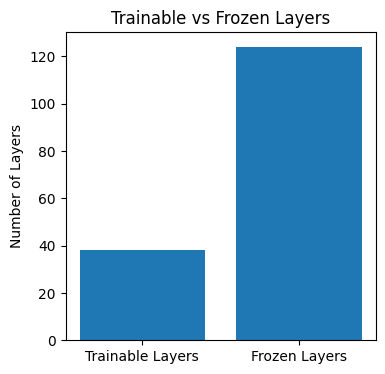

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt

# =============================
# BASE MODEL
# =============================
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# =============================
# FINE-TUNING STRATEGY
# =============================
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

# =============================
# CUSTOM CLASSIFIER HEAD
# =============================
x = GlobalAveragePooling2D()(base_model.output)

x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# =============================
# COMPILE MODEL
# =============================
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =============================
# VISUALIZATION 1: MODEL ARCHITECTURE
# =============================
plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    dpi=80
)

# =============================
# VISUALIZATION 2: TRAINABLE vs FROZEN LAYERS
# =============================
trainable_count = sum([1 for l in model.layers if l.trainable])
frozen_count = sum([1 for l in model.layers if not l.trainable])

plt.figure(figsize=(4,4))
plt.bar(["Trainable Layers", "Frozen Layers"],
        [trainable_count, frozen_count])
plt.title("Trainable vs Frozen Layers")
plt.ylabel("Number of Layers")
plt.show()


**BLOCK 7: Model Training**

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.3427 - loss: 7.7923
Epoch 1: val_accuracy improved from -inf to 0.59833, saving model to /content/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 395ms/step - accuracy: 0.3431 - loss: 7.7906 - val_accuracy: 0.5983 - val_loss: 6.8733 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.5423 - loss: 7.0237
Epoch 2: val_accuracy did not improve from 0.59833
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 182ms/step - accuracy: 0.5426 - loss: 7.0233 - val_accuracy: 0.5607 - val_loss: 7.1282 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.6373 - loss: 6.7859
Epoch 3: val_accuracy improved from 0.59833 to 0.70711, saving model to /content/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 188ms/step - accuracy: 0.6374 - loss: 6.7854 - val_accuracy: 0.7071 - val_loss: 6.6353 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms

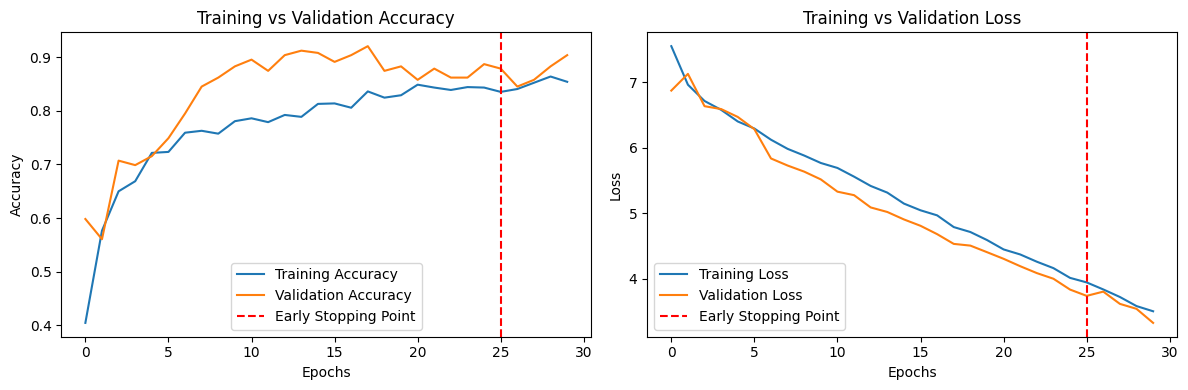

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

# =============================
# CALLBACKS
# =============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/content/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# =============================
# TRAIN MODEL
# =============================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# =============================
# VISUALIZATION 1: TRAIN vs VAL ACCURACY
# =============================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axvline(
    x=len(history.history['val_loss']) - early_stop.patience,
    color='r', linestyle='--', label='Early Stopping Point'
)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# =============================
# VISUALIZATION 2: TRAIN vs VAL LOSS
# =============================
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axvline(
    x=len(history.history['val_loss']) - early_stop.patience,
    color='r', linestyle='--', label='Early Stopping Point'
)
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# =============================
# VISUALIZATION 3: LEARNING RATE CHANGES
# =============================
lrs = history.history.get('lr')

if lrs:
    plt.figure(figsize=(6,4))
    plt.plot(lrs, marker='o')
    plt.title("Learning Rate Reduction (ReduceLROnPlateau)")
    plt.xlabel("Epochs")
    plt.ylabel("Learning Rate")
    plt.yscale("log")
    plt.show()


**BLOCK 8: Save Model to Drive**

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/skin_disease_mobilenetv2.keras"
model.save(MODEL_PATH)
print("✅ Model saved to Google Drive")


✅ Model saved to Google Drive


**BLOCK 9: Evaluation & Confusion Matrix**

30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step
📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Acne       0.89      0.95      0.92        60
     Arsenic       0.95      0.93      0.94        60
      Eczema       0.96      0.88      0.92        60
     Healthy       0.92      0.95      0.93        60

    accuracy                           0.93       240
   macro avg       0.93      0.93      0.93       240
weighted avg       0.93      0.93      0.93       240



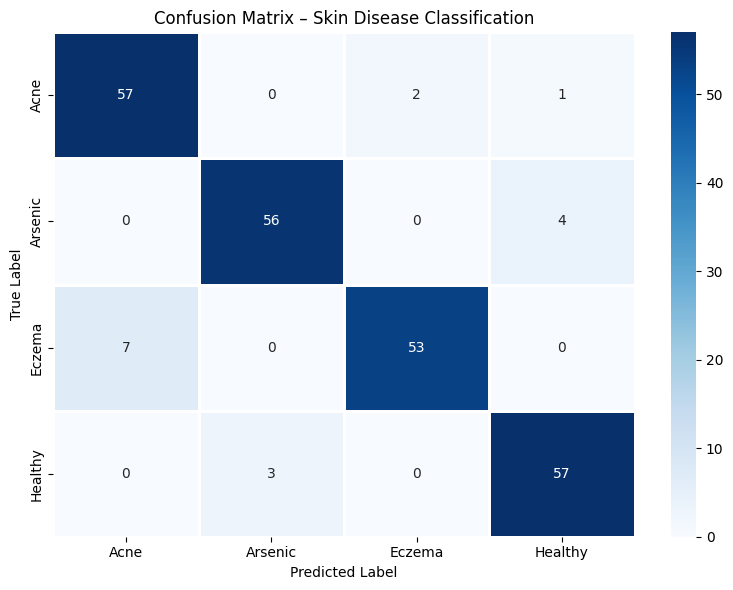

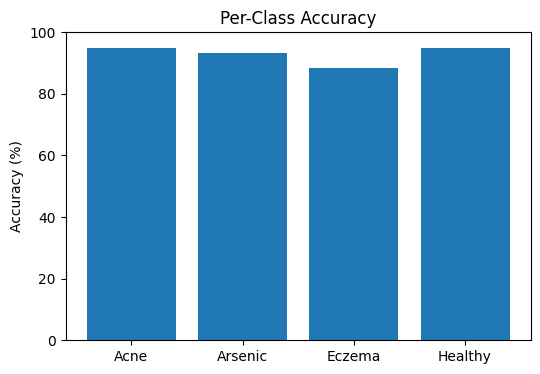

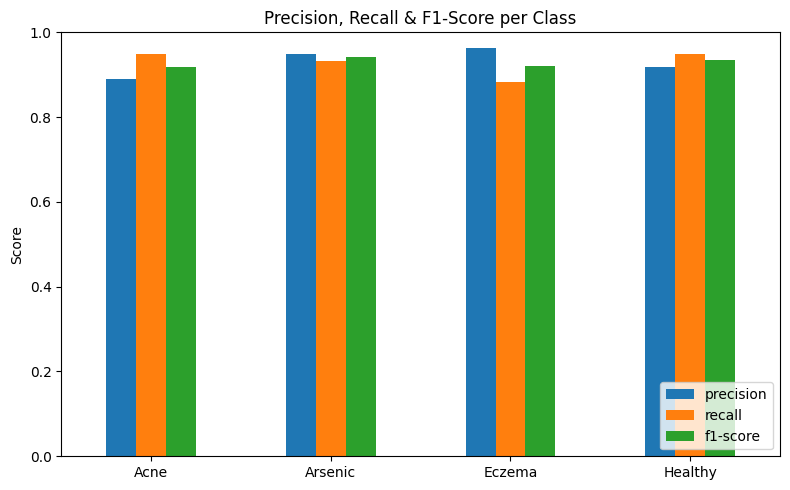

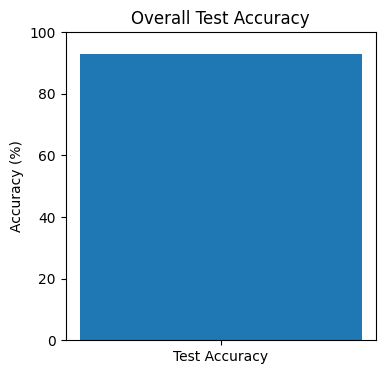


🎯 OVERALL TEST ACCURACY: 92.92%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =============================
# PREDICTIONS
# =============================
pred = model.predict(test_gen)
y_pred = np.argmax(pred, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# =============================
# CLASSIFICATION REPORT (TEXT)
# =============================
print("📊 CLASSIFICATION REPORT")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_true, y_pred, target_names=class_names))

# =============================
# CONFUSION MATRIX (HEATMAP)
# =============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=2,
    linecolor='white'
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Skin Disease Classification")
plt.tight_layout()
plt.show()

# =============================
# PER-CLASS ACCURACY (BAR CHART)
# =============================
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

plt.figure(figsize=(6,4))
plt.bar(class_names, per_class_acc)
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy")
plt.ylim(0,100)
plt.show()

# =============================
# PRECISION / RECALL / F1 VISUALIZATION
# =============================
metrics_df = pd.DataFrame(report).transpose().iloc[:-3][['precision','recall','f1-score']]

metrics_df.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Precision, Recall & F1-Score per Class")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# =============================
# OVERALL TEST ACCURACY VISUAL
# =============================
overall_acc = cm.diagonal().sum() / cm.sum() * 100

plt.figure(figsize=(4,4))
plt.bar(["Test Accuracy"], [overall_acc])
plt.ylabel("Accuracy (%)")
plt.title("Overall Test Accuracy")
plt.ylim(0,100)
plt.show()

print(f"\n🎯 OVERALL TEST ACCURACY: {overall_acc:.2f}%")


**BLOCK 10: Prediction Logic (Healthy vs Infected)**

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import os
from IPython.display import display, HTML, Image as IPImage
import ipywidgets as widgets
from io import BytesIO
from PIL import Image
import base64

# Get labels from your model
labels = list(test_gen.class_indices.keys())

def predict_disease(img_path):
    """Predict disease from image path"""
    try:
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_batch, verbose=0)
        predicted_class = labels[np.argmax(pred)]
        confidence = np.max(pred) * 100

        return predicted_class, confidence, pred[0]
    except Exception as e:
        return None, None, None

def image_to_base64(img_path):
    """Convert image to base64 for display"""
    img = Image.open(img_path)
    img.thumbnail((300, 300))
    buffered = BytesIO()
    img.save(buffered, format="JPEG")
    img_str = base64.b64encode(buffered.getvalue()).decode()
    return f"data:image/jpeg;base64,{img_str}"

def create_result_html(img_path, predicted_class, confidence, probabilities):
    """Create beautiful HTML result card"""
    img_base64 = image_to_base64(img_path)

    # Create probability bars
    prob_bars = ""
    for i, class_name in enumerate(labels):
        prob = probabilities[i] * 100
        color = "#4CAF50" if class_name == predicted_class else "#2196F3"
        prob_bars += f"""
        <div style="margin: 8px 0;">
            <div style="display: flex; justify-content: space-between; margin-bottom: 3px;">
                <span style="font-weight: 500;">{class_name}</span>
                <span style="color: #666;">{prob:.2f}%</span>
            </div>
            <div style="background: #e0e0e0; border-radius: 10px; height: 20px; overflow: hidden;">
                <div style="background: {color}; width: {prob}%; height: 100%; border-radius: 10px; transition: width 0.3s;"></div>
            </div>
        </div>
        """

    status_color = "#4CAF50" if predicted_class == "Healthy" else "#f44336"
    status_icon = "✓" if predicted_class == "Healthy" else "⚠"

    html = f"""
    <div style="background: white; border-radius: 15px; padding: 20px; margin: 15px 0; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border-left: 5px solid {status_color};">
        <div style="display: flex; gap: 20px; align-items: start;">
            <div style="flex-shrink: 0;">
                <img src="{img_base64}" style="border-radius: 10px; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
                <div style="text-align: center; margin-top: 10px; font-size: 12px; color: #666;">
                    {os.path.basename(img_path)}
                </div>
            </div>
            <div style="flex-grow: 1;">
                <div style="background: {status_color}; color: white; padding: 15px; border-radius: 10px; margin-bottom: 15px;">
                    <div style="font-size: 24px; font-weight: bold; margin-bottom: 5px;">
                        {status_icon} {predicted_class}
                    </div>
                    <div style="font-size: 18px; opacity: 0.9;">
                        Confidence: {confidence:.2f}%
                    </div>
                </div>
                <div style="background: #f5f5f5; padding: 15px; border-radius: 10px;">
                    <h3 style="margin-top: 0; color: #333;">Class Probabilities:</h3>
                    {prob_bars}
                </div>
            </div>
        </div>
    </div>
    """
    return html

def process_uploaded_files(uploaded_files):
    """Process single or multiple uploaded files"""
    output.clear_output()

    with output:
        display(HTML("""
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                    padding: 20px; border-radius: 15px; color: white; text-align: center; margin-bottom: 20px;">
            <h2 style="margin: 0;">🔬 Processing Results</h2>
        </div>
        """))

        if not uploaded_files:
            display(HTML('<p style="color: red; text-align: center;">❌ No files uploaded!</p>'))
            return

        for filename, file_info in uploaded_files.items():
            # Save uploaded file temporarily
            temp_path = f"/tmp/{filename}"
            with open(temp_path, 'wb') as f:
                f.write(file_info['content'])

            # Predict
            predicted_class, confidence, probabilities = predict_disease(temp_path)

            if predicted_class:
                result_html = create_result_html(temp_path, predicted_class, confidence, probabilities)
                display(HTML(result_html))
            else:
                display(HTML(f'<p style="color: red;">❌ Error processing {filename}</p>'))

            # Clean up
            os.remove(temp_path)

# Create beautiful GUI
display(HTML("""
<style>
    .upload-container {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 30px;
        border-radius: 20px;
        box-shadow: 0 10px 30px rgba(0,0,0,0.3);
        margin: 20px 0;
    }
    .upload-title {
        color: white;
        text-align: center;
        font-size: 32px;
        font-weight: bold;
        margin-bottom: 10px;
        text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
    }
    .upload-subtitle {
        color: rgba(255,255,255,0.9);
        text-align: center;
        font-size: 16px;
        margin-bottom: 20px;
    }
</style>

<div class="upload-container">
    <div class="upload-title">🌿 Plant Disease Detector</div>
    <div class="upload-subtitle">Upload single or multiple images for analysis</div>
</div>
"""))

# File uploader widget
uploader = widgets.FileUpload(
    accept='image/*',
    multiple=True,
    description='',
    style={'description_width': 'initial'}
)

# Upload button
upload_btn = widgets.Button(
    description='🚀 Analyze Images',
    button_style='success',
    layout=widgets.Layout(width='200px', height='50px'),
    style={'font_weight': 'bold'}
)

# Output area
output = widgets.Output()

# Button click handler
def on_upload_click(b):
    process_uploaded_files(uploader.value)

upload_btn.on_click(on_upload_click)

# Layout
display(HTML("""
<div style="background: white; padding: 20px; border-radius: 15px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h3 style="color: #333; margin-top: 0;">📁 Select Images:</h3>
</div>
"""))

display(uploader)
display(widgets.HBox([upload_btn], layout=widgets.Layout(justify_content='center', margin='20px 0')))
display(output)

display(HTML("""
<div style="background: #f0f0f0; padding: 15px; border-radius: 10px; margin-top: 20px; text-align: center;">
    <p style="color: #666; margin: 5px 0;">💡 <strong>Tip:</strong> You can select multiple images at once!</p>
    <p style="color: #666; margin: 5px 0;">🖼️ Supported formats: JPG, PNG, JPEG</p>
</div>
"""))


FileUpload(value={}, accept='image/*', multiple=True)

Output()